> ##### Import library

In [27]:
from ultralytics import YOLO

from mpl_toolkits.axes_grid1 import ImageGrid
import numpy as np
import cv2
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid

> ##### **Visualize Backpropagation Gradient**
**Load trained model**

In [28]:
model = YOLO("runs/detect/train/weights/best.pt")
model.model = model.model.cuda()

model.model.eval()

DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C2f(
      (cv1): Conv(
        (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(96, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
    

**preprocess for Grad-Cam**

In [29]:
def preprocess_image(img_path, img_size=640):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size))

    # Prepare tensor
    img = torch.from_numpy(img).permute(2,0,1).float() / 255.0  # HWC -> CHW
    img = img.unsqueeze(0).to(next(model.model.parameters()).device)  # [1,C,H,W]

    return img

**Hook for Grad-CAM**

capture the output and gradients of the last convolutional layer.

* remove hook before register_hook

In [30]:
layer = 19

activations = {}
gradients = {}

# Pick the last conv layer of YOLOv8 backbone (before Detect)
target_layer = model.model.model[layer] # adjust layer

target_layer._forward_hooks.clear()
target_layer._backward_hooks.clear()

print(target_layer)


def forward_hook(module, input, output):
    activations['value'] = output

def backward_hook(module, grad_in, grad_out):
    gradients['value'] = grad_out[0]
    
fwd_handle = target_layer.register_forward_hook(forward_hook)
bwd_handle = target_layer.register_backward_hook(backward_hook)

Conv(
  (conv): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn): BatchNorm2d(256, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
  (act): SiLU(inplace=True)
)


In [31]:
def apply_heatmap_overlay(img_path, heatmap):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img, 0.5, heatmap, 0.5, 0)
    return overlay

**Calculate Grad-CAM**

In [32]:
def calculate_grad_cam(img_tensor, shape):
    img_tensor = img_tensor.cuda()
    
    img_tensor.requires_grad_(True)
    
    # Forward pass through backbone to trigger hooks
    outputs = model.model(img_tensor)

    # Use objectness of the highest-scoring predicted box
    pred_tensor = outputs[0]  # [1, num_boxes, 85]
    # print(f"pred_tensor: {pred_tensor}")
    
    top_idx = pred_tensor[0,:,4].argmax() 
    print(f"top_idx: {top_idx}")
    
    pred_class = pred_tensor[0, top_idx, 5:].argmax()
    score_tensor = pred_tensor[0, top_idx, 5 + pred_class]
    
    # score_tensor = obj_scores[top_idx]
    print(f"score_tensor: {score_tensor}")

    # Backward pass to get gradients
    model.model.zero_grad()
    score_tensor.backward()    
    
    print("Activation:", activations['value'].shape)
    print("Gradient:", gradients['value'].shape)

    # Grad-CAM computation
    grad = gradients['value'][0]  # [C,H,W]

    act = activations['value'][0] # [C,H,W]
    
    print("Grad min/max:", grad.min().item(), grad.max().item())

    weights = grad.mean(dim=(1,2), keepdim=True)  # global average pooling
    
    cam = (weights * act).sum(dim=0)  # sum over channels
    
    cam = torch.relu(cam)
    cam = cam / (cam.max() + 1e-8)

    cam_np = cam.detach().cpu().numpy()
        
    cam_np = cv2.resize(cam_np, (shape[1], shape[0]))

    heatmap = cv2.applyColorMap(np.uint8(255*cam_np), cv2.COLORMAP_JET)
        
    return heatmap

In [35]:
def get_grad_cam(img_path, layer):
    img = cv2.imread(img_path)
    img_tensor = preprocess_image(img_path)
    heatmap = calculate_grad_cam(img_tensor, img.shape)
    output_image = apply_heatmap_overlay(img_path, heatmap)
    cv2.imwrite(f'heatmap/{img_path}-{layer}.jpg', output_image)
    return output_image

**Use Grad-CAM on test image**

top_idx: 2
score_tensor: 601.7374267578125
Activation: torch.Size([1, 256, 20, 20])
Gradient: torch.Size([1, 256, 20, 20])
Grad min/max: -1.075116515159607 0.6843165755271912


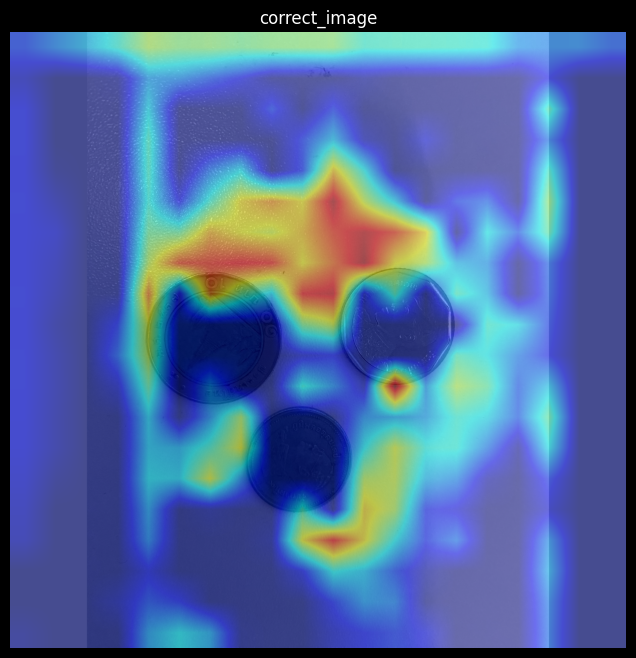

In [36]:
output_image = get_grad_cam('../test_images/two_five_ten.jpg', layer = layer)

plt.figure(figsize=(8,8))
plt.title('correct_image')
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

**REMOVE BEFORE RUNNING THE HOOK CELL AGAIN**

In [11]:
fwd_handle.remove()
bwd_handle.remove()

In [ ]:
fig = plt.figure(figsize=(20, 6))
grid = ImageGrid(fig, rect=111 , nrows_ncols=(4, 10))

for i, ax in enumerate(grid):
    im = ax.imshow(lin_result[i])
    ax.set_axis_off()
        
plt.show()


 
plt.figure(figsize=(8,8))
plt.title(img_path)
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()